In [1]:
%load_ext kedro.ipython

import numpy as np
import pandas as pd
import os
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

os.environ['KERAS_BACKEND'] = 'tensorflow'

# Note that Keras should only be imported after the backend
# has been configured. The backend cannot be changed once the
# package is imported.
import keras

random_state = catalog.load('params:model_options.random_state')
keras.utils.set_random_seed(random_state)

[01/11/25 15:59:14] INFO     Using                                                                  ]8;id=611022;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=62582;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\framework\project\__init__.py#270\270]8;;\
                             'c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\framewor                
                             k\project\rich_logging.yml' as logging configuration.                                 

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=483941;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=789274;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#61\61]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=327381;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=650253;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#63\63]8;;\

                    INFO     Resolved project path as: d:\UNIWERSYTET WARSZAWSKI\Machine Learning   ]8;id=921837;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=436472;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#178\178]8;;\
                             in Finance\II\Projects\ML_travel_insurance.                                           
                             To set a different path, run '%reload_kedro <project_root>'                           

[01/11/25 15:59:20] WARNING  c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\framework ]8;id=716057;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\warnings.py\warnings.py]8;;\:]8;id=306100;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\warnings.py#112\112]8;;\
                             \project\__init__.py:347: UserWarning: The                                            
                             'ml_travel_insurance.pipelines.data_processing' module does not expose                
                             a 'create_pipeline' function, so no pipelines defined therein will be                 
                             returned by 'find_pipelines'.                                                         
                               warnings.warn(                                                                      
                                                                                                                   

                    WARNING  c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\framework ]8;id=32315;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\warnings.py\warnings.py]8;;\:]8;id=295817;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\warnings.py#112\112]8;;\
                             \project\__init__.py:347: UserWarning: The                                            
                             'ml_travel_insurance.pipelines.data_science' module does not expose a                 
                             'create_pipeline' function, so no pipelines defined therein will be                   
                             returned by 'find_pipelines'.                                                         
                               warnings.warn(                                                                      
                                                                                                                   

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=94724;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=491977;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro_telemetry\plugin.py#233\233]8;;\
                             the product. No personal data or IP addresses are stored on our side. If              
                             you want to opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK`              
                             environment variables, or create a `.telemetry` file in the current                   
                             working directory with the contents `consent: false`. Read more at                    
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

[01/11/25 15:59:21] INFO     Kedro project ML_travel_insurance                                      ]8;id=716604;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=542184;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#144\144]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=852326;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=896842;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#145\145]8;;\
                             'pipelines'                                                                           

[01/11/25 15:59:29] INFO     Loading data from params:model_options.random_state                ]8;id=946948;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=514327;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\
                             (MemoryDataset)...                                                                    

In [2]:
X_train, y_train = catalog.load('TI_train_feature'), catalog.load('TI_y_train_feature')
X_test, y_test = catalog.load('TI_test_feature'), catalog.load('TI_y_test_feature')

kX_train, kX_test = X_train.astype(np.float64).values, X_test.astype(np.float64).values
kY_train, kY_test = y_train.values, y_test.values

                    INFO     Loading data from TI_train_feature (CSVDataset)...                 ]8;id=865291;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=841847;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_y_train_feature (CSVDataset)...               ]8;id=203068;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=283372;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_test_feature (CSVDataset)...                  ]8;id=130303;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=916638;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

[01/11/25 15:59:30] INFO     Loading data from TI_y_test_feature (CSVDataset)...                ]8;id=182812;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=641486;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

In [3]:
kX_train.dtype

dtype('float64')

In [4]:
model = keras.Sequential(
    [
        keras.Input(shape=kX_train.shape[1:]),
        keras.layers.Dense(256, activation="relu"),
        keras.layers.Dense(256, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(256, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1, activation="sigmoid"),
    ]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,241 (540.00 KB)

 Trainable params: 138,241 (540.00 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
counts = np.bincount(kY_train[:, 0])


metrics = [
    keras.metrics.FalseNegatives(name="fn"),
    keras.metrics.FalsePositives(name="fp"),
    keras.metrics.TrueNegatives(name="tn"),
    keras.metrics.TruePositives(name="tp"),
    keras.metrics.Precision(name="precision"),
    keras.metrics.Recall(name="recall"),
    keras.metrics.F1Score(threshold=0.5, name='f1'),
]

model.compile(
    optimizer=keras.optimizers.Adam(1e-2), loss="binary_crossentropy", metrics=metrics
)

# callbacks = [keras.callbacks.ModelCheckpoint("fraud_model_at_epoch_{epoch}.keras")]
class_weight = {0: 1 / counts[0], 1: 1 / counts[1]}

In [6]:
nn_fit = model.fit(
    kX_train,
    kY_train,
    batch_size=8092,
    epochs=50,
    verbose=2,
    # callbacks=callbacks,
    validation_data=(kX_test, kY_test),
    class_weight=class_weight,
)

Epoch 1/50
7/7 - 7s - 1s/step - f1: 0.0333 - fn: 317.0000 - fp: 24354.0000 - loss: 2.7639e-04 - precision: 0.0172 - recall: 0.5728 - tn: 25564.0000 - tp: 425.0000 - val_f1: 0.0290 - val_fn: 0.0000e+00 - val_fp: 12389.0000 - val_loss: 1.8740 - val_precision: 0.0147 - val_recall: 1.0000 - val_tn: 92.0000 - val_tp: 185.0000
Epoch 2/50
7/7 - 1s - 96ms/step - f1: 0.0393 - fn: 355.0000 - fp: 18566.0000 - loss: 3.2633e-05 - precision: 0.0204 - recall: 0.5216 - tn: 31352.0000 - tp: 387.0000 - val_f1: 0.0469 - val_fn: 40.0000 - val_fp: 5854.0000 - val_loss: 0.8163 - val_precision: 0.0242 - val_recall: 0.7838 - val_tn: 6627.0000 - val_tp: 145.0000
Epoch 3/50
7/7 - 1s - 80ms/step - f1: 0.0502 - fn: 268.0000 - fp: 17678.0000 - loss: 2.5519e-05 - precision: 0.0261 - recall: 0.6388 - tn: 32240.0000 - tp: 474.0000 - val_f1: 0.0618 - val_fn: 74.0000 - val_fp: 3296.0000 - val_loss: 0.5511 - val_precision: 0.0326 - val_recall: 0.6000 - val_tn: 9185.0000 - val_tp: 111.0000
Epoch 4/50
7/7 - 1s - 82ms/step

396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


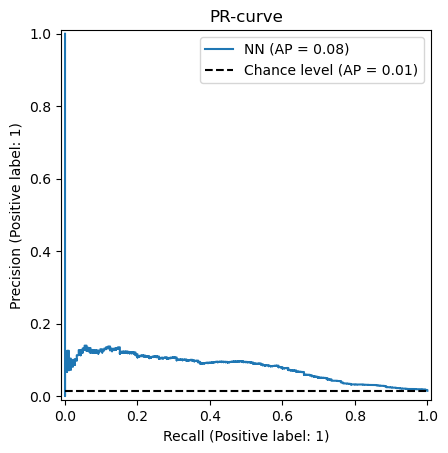

In [7]:

y_pred = model.predict(kX_test)

display = PrecisionRecallDisplay.from_predictions(
    kY_test.T[0], y_pred.T[0], name="NN", plot_chance_level=True
)
_ = display.ax_.set_title("PR-curve")
plt.legend()
plt.show()